# Optimal Transport based ICA versus FastICA - linear setting

### We compare the performance of OT based ICA and FastICA over varying number of dimensions and sample size of simulation with LBGFS optimization instead of SGD.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import FastICA
from tqdm.notebook import tqdm

# IMPORT YOUR PACKAGE
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Metrics & Simulation Helpers
# ==========================================

def amari_error(W_est, A_true):
    """
    Computes the Amari Performance Index.
    0.0 = Perfect recovery (up to permutation/scale).
    """
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
        
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    
    # Sum over rows
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    
    # Sum over cols
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    
    return (term1 + term2) / (2 * n)

In [3]:
def get_whitening_matrix(X_torch):
    """
    Helper to reconstruct the Whitening Matrix W_white used inside your class.
    We need this to calculate the Total Unmixing Matrix: W_total = W_sphere @ W_white
    """
    n_samples = X_torch.shape[1]
    X_centered = X_torch - torch.mean(X_torch, dim=1, keepdim=True)
    cov = torch.matmul(X_centered, X_centered.t()) / (n_samples - 1)
    D, E = torch.linalg.eigh(cov)
    D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
    W = torch.matmul(D_inv_sqrt, E.T)
    return W.cpu().numpy()

def generate_dataset(n_dim, n_samples, seed=None, dist_type='laplace'):
    """
    Generates mixed data where ALL sources come from the same distribution family.
    
    Parameters:
    -----------
    dist_type : str
        'laplace'   (Super-Gaussian, sharp peak) - Standard ICA Benchmark
        'uniform'   (Sub-Gaussian, flat)         - Hard for some algorithms
        'student-t' (Heavy-tailed, df=3)         - Good for robustness check
        'beta'      (U-shaped, bimodal-ish)      
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    sources = []
    for _ in range(n_dim):
        if dist_type == 'laplace':
            # Standard Laplace (Mean=0, Scale=1)
            s = np.random.laplace(0, 1, n_samples)
            
        elif dist_type == 'uniform':
            # Unit variance Uniform [-sqrt(3), sqrt(3)]
            s = np.random.uniform(-np.sqrt(3), np.sqrt(3), n_samples)
            
        elif dist_type == 'student-t':
            # Heavy tails (Degrees of Freedom = 3)
            s = np.random.standard_t(df=3, size=n_samples)
            
        elif dist_type == 'beta':
            # Beta(0.5, 0.5) is "Arcsine" (U-shaped)
            s = np.random.beta(0.5, 0.5, size=n_samples)
            s = (s - np.mean(s)) / np.std(s) # Normalize
            
        else:
            raise ValueError(f"Unknown dist_type: {dist_type}")
            
        sources.append(s)
        
    S = np.stack(sources)
    
    # Random Mixing Matrix with condition number check
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [4]:
# ==========================================
# 2. Experiment Configuration
# ==========================================

# --- Laptop Settings (Fast/Debug) ---
DIMENSION_RANGE = list(range(2, 31))      # Varying D
SAMPLE_SIZE_RANGE = [500, 1000, 5000] + list(range(10000, 100001, 5000)) # Varying N
N_TRIALS = 3                          # Repeats per point (for Error Bars)

# --- Cluster Settings---
# DIMENSION_RANGE = [2, 4, 8, 16, 32]
# SAMPLE_SIZE_RANGE = [500, 1000, 5000, 10000, 50000]
# N_TRIALS = 20

# Fixed Constants for the opposing experiment
FIXED_DIM = 6         # Used when varying Sample Size
FIXED_SAMPLES = 2000  # Used when varying Dimensions

print(f"--- Configuration ---")
print(f"Varying Dimensions: {DIMENSION_RANGE} (at N={FIXED_SAMPLES})")
print(f"Varying Samples:    {SAMPLE_SIZE_RANGE} (at D={FIXED_DIM})")
print(f"Trials per setting: {N_TRIALS}")

--- Configuration ---
Varying Dimensions: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30] (at N=2000)
Varying Samples:    [500, 1000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000] (at D=6)
Trials per setting: 3


In [5]:
# ==========================================
# 3. Main Experiment Loop (L-BFGS Enabled)
# ==========================================
results = []

# --- Experiment A: Varying Dimensions ---
print("\nRunning Experiment 1: Varying Dimensions...")
for dim in tqdm(DIMENSION_RANGE, desc="Dimensions"):
    for trial in range(N_TRIALS):
        # 1. Data Gen
        X_torch, A_true = generate_dataset(n_dim=dim, n_samples=FIXED_SAMPLES, seed=trial, dist_type='laplace')
        X_np = X_torch.numpy()
        
        # 2. FastICA
        try:
            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-3, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_ 
            score_fast = amari_error(W_fast, A_true)
        except Exception as e:
            score_fast = np.nan
            
        # 3. WassersteinICA (Deflation + L-BFGS Refinement)
        try:
            ica = WassersteinICA(X_torch)
            ica.whiten()
            
            # --- PHASE 1: Deflationary Initialization (Rough Draft with SGD) ---
            extracted_ws = []
            for _ in range(dim):
                prev = torch.stack(extracted_ws) if extracted_ws else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, 
                    max_iter=200, 
                    lr=0.1, 
                    continuous=True,
                    n_restarts=3
                )
                extracted_ws.append(w)
            
            W_deflation = torch.stack(extracted_ws)
            
            # --- PHASE 2: Symmetric Refinement (L-BFGS Polish) ---
            W_sphere = ica.optimize_symmetric(
                n_components=dim,
                init_w=W_deflation,
                max_iter=50,         # L-BFGS needs fewer iterations
                lr=1.0,              # Standard LR for L-BFGS
                optimizer='lbfgs',   # <--- ENABLE L-BFGS
                penalty_weight=10.0
            )
            
            # Reconstruct Total W
            W_white = get_whitening_matrix(X_torch) 
            W_wass = W_sphere.cpu().numpy() @ W_white
            
            score_wass = amari_error(W_wass, A_true)
        except Exception as e:
            print(f"Wasserstein Fail (Dim {dim}): {e}")
            score_wass = np.nan

        results.append({'Exp': 'Varying Dim', 'X': dim, 'N': FIXED_SAMPLES, 'Method': 'FastICA', 'Amari': score_fast})
        results.append({'Exp': 'Varying Dim', 'X': dim, 'N': FIXED_SAMPLES, 'Method': 'WassersteinICA', 'Amari': score_wass})


Running Experiment 1: Varying Dimensions...


Dimensions:   0%|          | 0/29 [00:00<?, ?it/s]

In [6]:
# --- Experiment B: Varying Sample Size ---
print("\nRunning Experiment 2: Varying Sample Size...")
for n in tqdm(SAMPLE_SIZE_RANGE, desc="Samples"):
    for trial in range(N_TRIALS):
        # 1. Data Gen
        X_torch, A_true = generate_dataset(n_dim=FIXED_DIM, n_samples=n, seed=trial + 1000, dist_type='laplace')
        X_np = X_torch.numpy()
        
        # 2. FastICA
        try:
            fast_ica = FastICA(n_components=FIXED_DIM, max_iter=2000, tol=1e-3, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_ 
            score_fast = amari_error(W_fast, A_true)
        except:
            score_fast = np.nan
            
        # 3. WassersteinICA
        try:
            ica = WassersteinICA(X_torch)
            ica.whiten()
            
            # Phase 1
            extracted_ws = []
            for _ in range(FIXED_DIM):
                prev = torch.stack(extracted_ws) if extracted_ws else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, 
                    max_iter=200, 
                    lr=0.1, 
                    continuous=True,
                    n_restarts=3
                )
                extracted_ws.append(w)
            
            W_deflation = torch.stack(extracted_ws)

            # Phase 2 (L-BFGS)
            W_sphere = ica.optimize_symmetric(
                n_components=FIXED_DIM,
                init_w=W_deflation,
                max_iter=50,
                lr=1.0,
                optimizer='lbfgs',
                penalty_weight=10.0
            )
            
            W_white = get_whitening_matrix(X_torch)
            W_wass = W_sphere.cpu().numpy() @ W_white
            
            score_wass = amari_error(W_wass, A_true)
        except Exception as e:
            print(f"Wasserstein Fail (N {n}): {e}")
            score_wass = np.nan

        results.append({'Exp': 'Varying N', 'X': n, 'N': n, 'Method': 'FastICA', 'Amari': score_fast})
        results.append({'Exp': 'Varying N', 'X': n, 'N': n, 'Method': 'WassersteinICA', 'Amari': score_wass})

df_results = pd.DataFrame(results)


Running Experiment 2: Varying Sample Size...


Samples:   0%|          | 0/22 [00:00<?, ?it/s]

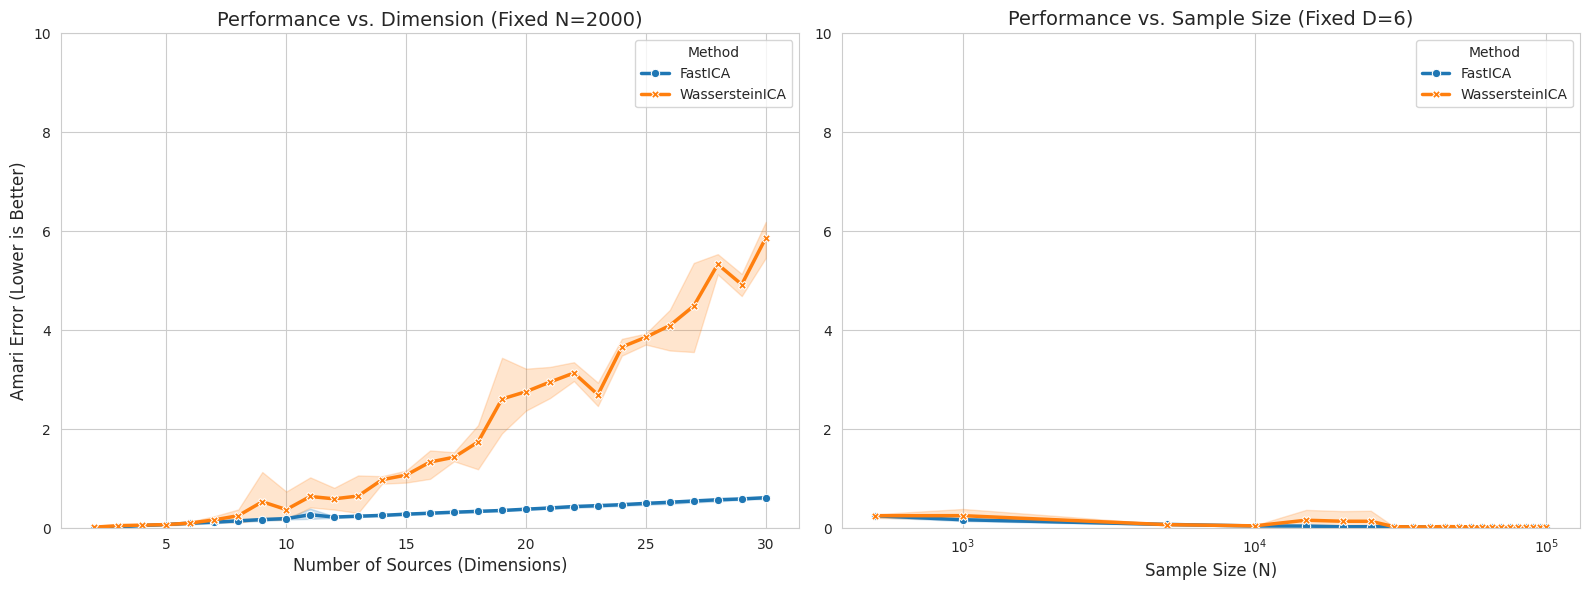


--- Summary Statistics ---


mean     std
Exp         X      Method                        
Varying Dim 2      FastICA         0.0117  0.0050
                   WassersteinICA  0.0196  0.0214
            3      FastICA         0.0254  0.0122
                   WassersteinICA  0.0502  0.0124
            4      FastICA         0.0529  0.0085
...                                   ...     ...
Varying N   90000  WassersteinICA  0.0200  0.0062
            95000  FastICA         0.0153  0.0013
                   WassersteinICA  0.0226  0.0085
            100000 FastICA         0.0138  0.0028
                   WassersteinICA  0.0131  0.0032

[102 rows x 2 columns]

In [9]:
# ==========================================
# 4. Plotting Results
# ==========================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data_dim = df_results[df_results['Exp'] == 'Varying Dim']
sns.lineplot(
    data=data_dim, x='X', y='Amari', hue='Method', style='Method',
    markers=True, dashes=False, linewidth=2.5, ax=axes[0], errorbar=('ci',95)
)
axes[0].set_title(f"Performance vs. Dimension (Fixed N={FIXED_SAMPLES})", fontsize=14)
axes[0].set_xlabel("Number of Sources (Dimensions)", fontsize=12)
axes[0].set_ylabel("Amari Error (Lower is Better)", fontsize=12)
axes[0].set_ylim(0, 10.0) 

data_n = df_results[df_results['Exp'] == 'Varying N']
sns.lineplot(
    data=data_n, x='X', y='Amari', hue='Method', style='Method',
    markers=True, dashes=False, linewidth=2.5, ax=axes[1], errorbar=('ci',95)
)
axes[1].set_title(f"Performance vs. Sample Size (Fixed D={FIXED_DIM})", fontsize=14)
axes[1].set_xlabel("Sample Size (N)", fontsize=12)
axes[1].set_xscale("log") 
axes[1].set_ylabel("")
axes[1].set_ylim(0, 10.0)

plt.tight_layout()
plt.show()

print("\n--- Summary Statistics ---")
display(df_results.groupby(['Exp', 'X', 'Method'])['Amari'].agg(['mean', 'std']).round(4))


--- Running Qualitative Check (Dim=10) ---


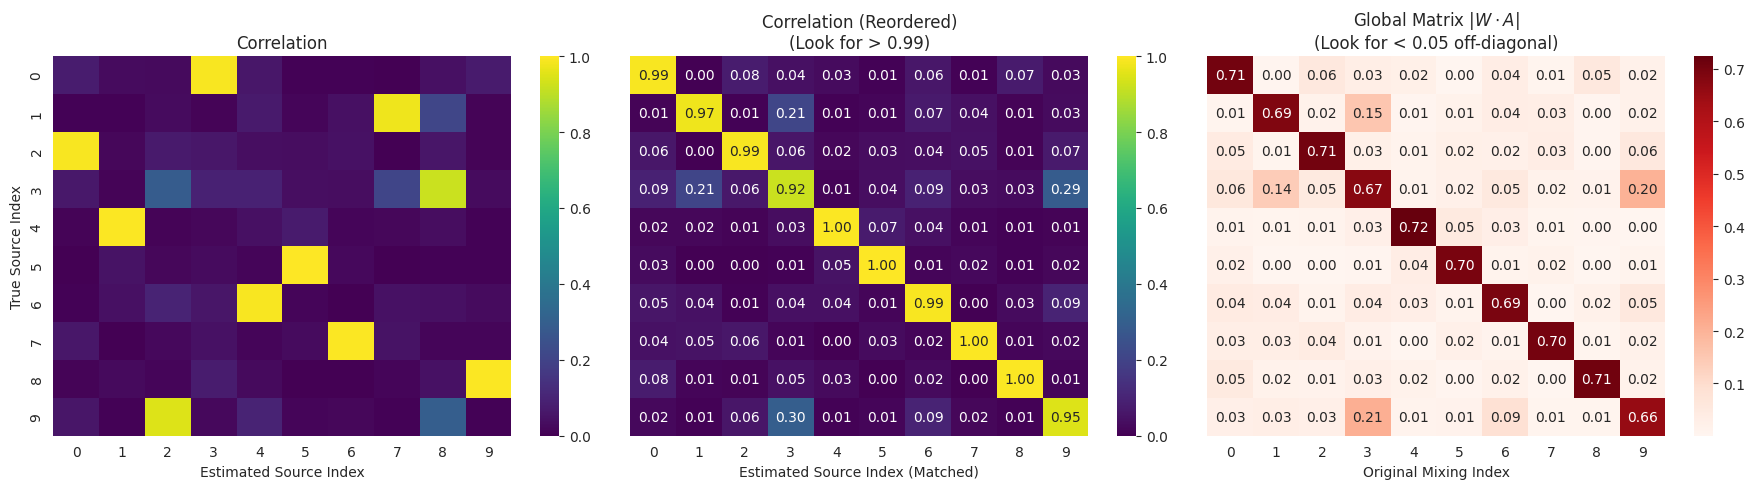

In [11]:
# ==========================================
# 5. Qualitative Analysis (L-BFGS Enabled)
# ==========================================
from scipy.optimize import linear_sum_assignment

def qualitative_check(n_dim=6, n_samples=2000):
    print(f"\n--- Running Qualitative Check (Dim={n_dim}) ---")
    
    # 1. Data Gen
    X_torch, A_true = generate_dataset(n_dim=n_dim, n_samples=n_samples, seed=42, dist_type='laplace')
    X_np = X_torch.numpy()
    S_true = np.linalg.inv(A_true) @ X_np
    
    # 2. Wasserstein ICA
    ica = WassersteinICA(X_torch)
    ica.whiten()
    
    # Phase 1
    extracted_ws = []
    for _ in range(n_dim):
        prev = torch.stack(extracted_ws) if extracted_ws else None
        w, _ = ica.optimize_wasserstein2(
            prev_components=prev, max_iter=200, lr=0.1, continuous=True, n_restarts=3
        )
        extracted_ws.append(w)
    W_deflation = torch.stack(extracted_ws)
    
    # Phase 2 (L-BFGS Polish)
    W_sphere = ica.optimize_symmetric(
        n_components=n_dim, 
        init_w=W_deflation, 
        max_iter=50, 
        lr=1.0, 
        optimizer='lbfgs', 
        penalty_weight=10.0
    )
    
    # Get Total W
    W_white = get_whitening_matrix(X_torch)
    W_est = W_sphere.cpu().numpy() @ W_white
    S_est = W_est @ X_np

    # 3. Match Sources
    corr_mat = np.zeros((n_dim, n_dim))
    for i in range(n_dim):
        for j in range(n_dim):
            corr_mat[i, j] = np.abs(np.corrcoef(S_true[i], S_est[j])[0, 1])
    
    row_ind, col_ind = linear_sum_assignment(-corr_mat)
    S_est_ordered = S_est[col_ind]
    corr_mat_ordered = corr_mat[:, col_ind]
    
    # 4. Global Matrix
    P = np.abs(W_est @ A_true)
    P_ordered = P[col_ind, :]

    # Visuals
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.heatmap(corr_mat, ax=axes[0], cmap="viridis", vmin=0, vmax=1, annot=False)
    axes[0].set_title("Correlation")
    axes[0].set_xlabel("Estimated Source Index")
    axes[0].set_ylabel("True Source Index")

    sns.heatmap(corr_mat_ordered, ax=axes[1], cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f")
    axes[1].set_title("Correlation (Reordered)\n(Look for > 0.99)")
    axes[1].set_xlabel("Estimated Source Index (Matched)")
    axes[1].set_yticks([])

    sns.heatmap(P_ordered, ax=axes[2], cmap="Reds", annot=True, fmt=".2f")
    axes[2].set_title("Global Matrix $|W \\cdot A|$\n(Look for < 0.05 off-diagonal)")
    axes[2].set_xlabel("Original Mixing Index")
    axes[2].set_yticks([])

    plt.tight_layout()
    plt.show()

qualitative_check(n_dim=10)